# Results Summary — Test Set

Consolidated comparison of all configurations on the **test split** (baseline vs every regularization, the random-search-tuned augmentation config, and the higher-resolution run). Everything is reported on test only, as mean ± standard error over the available seeds.

1. Overall test metrics per configuration (mAP50-95, dice, precision, recall)
2. Per-class test dice per configuration
3. Summary table

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

CLASSES = ['bicycle', 'bus', 'car', 'motorcycle', 'person', 'rider', 'train', 'truck']
METRICS = {'mask_mAP50_95': 'mAP50-95', 'mask_dice': 'dice',
           'mask_precision': 'precision', 'mask_recall': 'recall'}
CONFIGS = ['baseline', 'weight decay', 'augmentation', 'random search', 'higher res']
COLORS = {'baseline': '#999999', 'weight decay': '#C73E1D', 'augmentation': '#6A994E',
          'random search': '#E67E22', 'higher res': '#2E86AB'}
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})

# Minimal results export: one row per (config, seed), test metrics only.
# 'config' is precomputed (the per-run W&B exports have been consolidated into this file).
df = pd.read_csv(Path('..') / 'combined_results.csv')
present = [c for c in CONFIGS if c in set(df['config'])]

print('configs and seeds:')
for cfg in present:
    seeds = sorted(df.loc[df['config'] == cfg, 'seed'].dropna().astype(int))
    print(f'  {cfg:14s} n={len(seeds)}  seeds={seeds}')

configs and seeds:
  baseline       n=3  seeds=[0, 1, 42]
  weight decay   n=3  seeds=[0, 1, 42]
  augmentation   n=3  seeds=[0, 1, 42]
  random search  n=3  seeds=[0, 0, 1]
  higher res     n=3  seeds=[0, 1, 42]


## 1. Overall test metrics per configuration

Mean ± SE over seeds. The **weight decay** config is the `yolo-seg-reg-wd-001*` runs (wd=1e-3 + `label_smoothing=0.05`, 3 seeds). The former separate *L2 + LS* run (`yolo-seg-reg-l2-ls`, wd=2e-3, single seed) used the same recipe with only a different wd value, so it is dropped to keep one clean weight-decay configuration. The **random search** config is the single best augmentation setting (tuned `copy_paste`/`scale`) found by the 4.5 sweep, re-run over 3 seeds (`4.5 random seed` group).

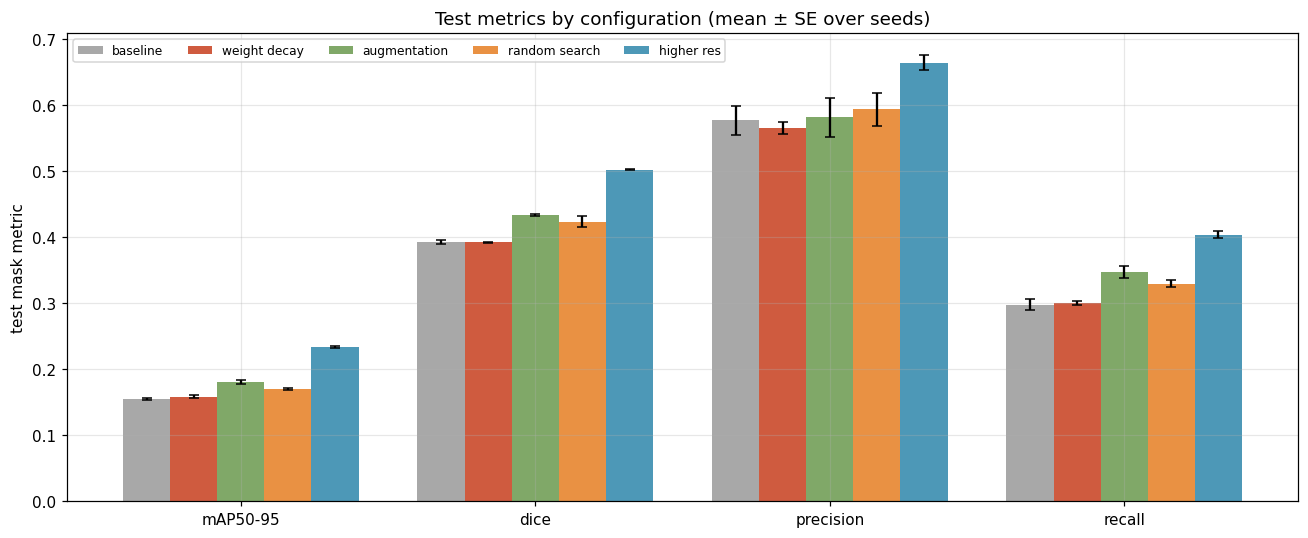

In [2]:
x = np.arange(len(METRICS)); w = 0.8 / len(present)
fig, ax = plt.subplots(figsize=(12, 5))
for i, cfg in enumerate(present):
    grp = df[df['config'] == cfg]
    means = [grp[f'test/{m}'].mean() for m in METRICS]
    errs = [np.nan_to_num(grp[f'test/{m}'].sem()) for m in METRICS]
    ax.bar(x + (i - (len(present) - 1) / 2) * w, means, w, yerr=errs, capsize=3,
           color=COLORS[cfg], alpha=0.85, label=cfg)
ax.set_xticks(x, list(METRICS.values()))
ax.set_ylabel('test mask metric')
ax.set_title('Test metrics by configuration (mean ± SE over seeds)')
ax.legend(ncol=len(present), fontsize=8); plt.tight_layout(); plt.show()

## 2. Per-class test dice per configuration

Heat map of the per-class test dice, averaged over seeds. Rows are configurations, columns are classes. This shows where each configuration helps and which classes stay weak.

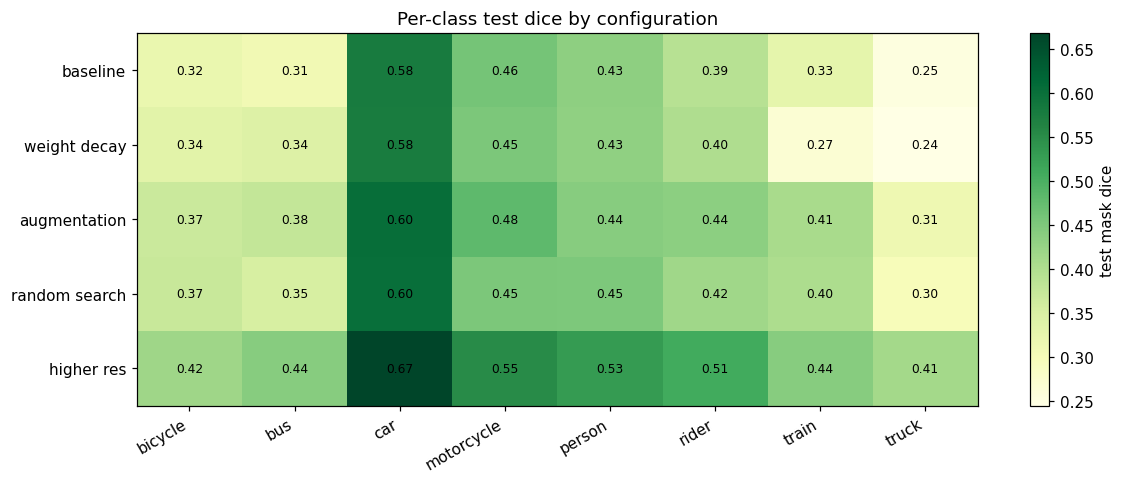

In [3]:
mat = np.array([[df.loc[df['config'] == cfg, f'class/test_mask_dice/{cls}'].mean()
                 for cls in CLASSES] for cfg in present])

fig, ax = plt.subplots(figsize=(11, 4.5))
im = ax.imshow(mat, aspect='auto', cmap='YlGn')
ax.set_xticks(range(len(CLASSES)), CLASSES, rotation=30, ha='right')
ax.set_yticks(range(len(present)), present)
for i in range(len(present)):
    for j in range(len(CLASSES)):
        ax.text(j, i, f'{mat[i, j]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax, label='test mask dice')
ax.set_title('Per-class test dice by configuration')
ax.grid(False); plt.tight_layout(); plt.show()

## 3. Summary table

Test metrics per configuration as mean ± SE, with the improvement over the baseline on the primary metric (mask mAP50-95).

In [4]:
base_map = df.loc[df['config'] == 'baseline', 'test/mask_mAP50_95'].mean()
rows = []
for cfg in present:
    grp = df[df['config'] == cfg]
    row = {'config': cfg, 'n': len(grp)}
    for m, lb in METRICS.items():
        row[lb] = f"{grp[f'test/{m}'].mean():.3f} ± {np.nan_to_num(grp[f'test/{m}'].sem()):.3f}"
    row['ΔmAP vs base'] = f"{grp['test/mask_mAP50_95'].mean() - base_map:+.3f}"
    rows.append(row)
print(pd.DataFrame(rows).to_string(index=False))

       config  n      mAP50-95          dice     precision        recall ΔmAP vs base
     baseline  3 0.155 ± 0.001 0.392 ± 0.003 0.577 ± 0.022 0.298 ± 0.009       +0.000
 weight decay  3 0.159 ± 0.002 0.392 ± 0.001 0.566 ± 0.009 0.300 ± 0.003       +0.004
 augmentation  3 0.180 ± 0.003 0.433 ± 0.001 0.582 ± 0.030 0.347 ± 0.009       +0.025
random search  3 0.170 ± 0.002 0.424 ± 0.008 0.593 ± 0.024 0.330 ± 0.006       +0.016
   higher res  3 0.234 ± 0.001 0.502 ± 0.001 0.664 ± 0.011 0.404 ± 0.005       +0.079
